In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
random.randint(140,170)

143

In [21]:
data=[]
for i in range(50):
    # 여자 데이터(키와 몸무게) 추가
    data.append([random.randint(40,70),random.randint(140,170)])
    # 남자 데이터(키와 몸무게) 추가
    data.append([random.randint(60,95),random.randint(160,195)])

In [22]:
print('여자 몸무게(x축):',[female[0] for female in data[::2]])
print('여자 키(y축):',[female[1] for female in data[::2]])    

print('남자 몸무게(x축):',[male[0] for male in data[1::2]])
print('남자 키(y축):',[male[1] for male in data[1::2]])                     

여자 몸무게(x축): [51, 46, 52, 64, 69, 58, 54, 42, 56, 55, 49, 52, 40, 58, 65, 60, 57, 44, 55, 63, 47, 62, 63, 67, 50, 47, 67, 70, 44, 50, 56, 68, 42, 59, 52, 68, 48, 45, 46, 42, 51, 56, 50, 64, 69, 40, 65, 40, 49, 70]
여자 키(y축): [143, 161, 170, 162, 152, 157, 158, 148, 166, 143, 166, 158, 149, 160, 166, 168, 169, 140, 167, 142, 153, 169, 163, 169, 168, 170, 151, 143, 164, 141, 149, 169, 150, 153, 147, 156, 163, 167, 145, 153, 165, 156, 149, 142, 155, 154, 141, 152, 151, 170]
남자 몸무게(x축): [74, 69, 80, 95, 95, 65, 79, 76, 83, 90, 74, 84, 68, 72, 67, 88, 84, 76, 83, 64, 62, 73, 83, 66, 64, 75, 62, 90, 76, 83, 77, 60, 71, 94, 80, 87, 61, 84, 65, 67, 70, 75, 66, 63, 63, 66, 90, 83, 69, 73]
남자 키(y축): [176, 186, 182, 188, 164, 164, 165, 193, 179, 183, 161, 162, 167, 161, 174, 169, 168, 193, 186, 174, 176, 191, 184, 184, 170, 174, 173, 173, 187, 177, 194, 165, 165, 168, 174, 170, 162, 172, 186, 167, 168, 169, 162, 172, 174, 186, 175, 195, 163, 176]


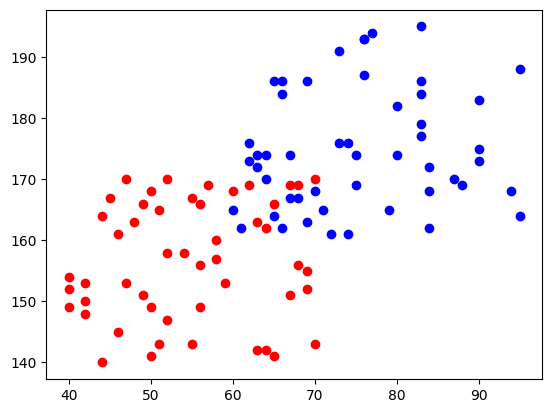

In [23]:
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]],'o',color='b')


# 2. 군집화 로직

In [26]:
# 초기 랜덤 지점 2개
random_points=[
    [random.randint(40,90),random.randint(140,195)],
    [random.randint(40,90),random.randint(140,195)]
]
random_points[0],random_points[1]

([81, 142], [59, 158])

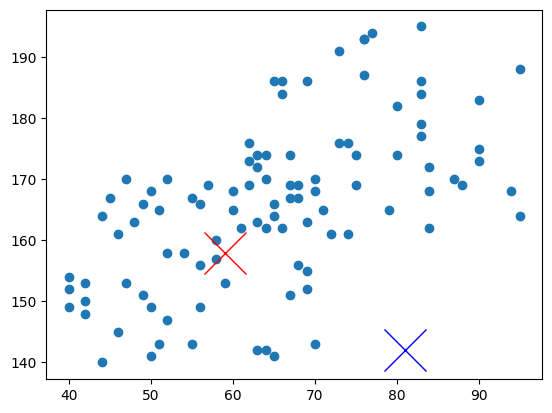

In [27]:
plt.plot([d[0] for d in data],
        [d[1] for d in data],'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30,color='b')# 기준점 0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30,color='r')# 기준점 1

In [37]:
# 두점거리를 return하는 함수 점은[50,150]
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
print(dist([3,4],[0,0]))
print(dist([5,7],[-1,-1]))

5.0
10.0


In [38]:
 # random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group0.append(d)
    else:
        group1.append(d)
len(group0),len(group1)

(10, 90)

In [40]:
# group0과 group1 중심점으로 기준점을 이용
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX,group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX,group1_meanY]
random_points

[[84.7, 163.3], [62.82222222222222, 165.96666666666667]]